# CS 432 Databases — Assignment 2
# QueryCraft
# B+ Tree Database Management System: Implementation, Analysis & Visualisation

**Course:** CS 432 – Databases  
**Track:** 1 | **Assignment:** 2

**GitHub Link:** https://github.com/nachiketpatil0105/stay_ease/tree/main/CS432_Track1_Submission

**Video Link:** https://www.youtube.com/watch?v=zy84JT_yegc

---

## Table of Contents
1. [Introduction](#1-introduction)
2. [Implementation](#2-implementation)
3. [Performance Analysis](#3-performance-analysis)
4. [Visualisation](#4-visualisation)
5. [Performance Testing & Plots](#5-performance-testing--plots)
6. [Video Demonstration](#6-video-demonstration)
7. [Conclusion](#7-conclusion)

---
## 1. Introduction

### Problem Statement

Modern database systems must handle millions of records with response times measured in milliseconds. A naive approach — storing records in an unsorted list — gives **O(n)** time for search, range queries, and deletion. As dataset size grows, this linear cost becomes a hard bottleneck.

### Proposed Solution: B+ Tree DBMS

A **B+ Tree** is the backbone indexing structure of virtually every production DBMS (MySQL InnoDB, PostgreSQL, Oracle DB). Its design guarantees:

| Property | Detail |
|---|---|
| All data stored at leaves | Internal nodes are pure routing — only leaf nodes hold actual records |
| Sorted leaf linked list | Leaves are chained via `next_leaf` pointers, enabling O(k) range scans |
| Perfectly balanced height | Every leaf sits at the same depth → O(log n) for all operations |
| Order `m` capacity rule | Each non-root node holds between ⌈m/2⌉−1 and m−1 keys |

### Objectives
1. Implement a complete B+ Tree supporting insert, delete, search, range query, and update.
2. Benchmark it against a brute-force list-based database (`BruteForceDB`).
3. Visualise the tree structure using Graphviz at different stages.
4. Present findings through Matplotlib performance plots and benchmark tables.

---
## 2. Implementation

### 2.1 Imports

In [1]:
from graphviz import Digraph
import random
import time
import tracemalloc
import matplotlib.pyplot as plt
import pandas as pd
import math
from IPython.display import display
import sys
sys.path.append('database')

from bplustree import BPlusTreeNode, BPlusTree
from bruteforce import BruteForceDB

print("All imports successful.")

All imports successful.


### 2.2 BPlusTreeNode Class

The `BPlusTreeNode` class is the fundamental building block of the tree. Each node stores:

- **`keys`** — a sorted list used for routing (internal nodes) or record indexing (leaf nodes).
- **`values`** — actual database records; populated **only** in leaf nodes.
- **`children`** — pointers to child nodes; populated **only** in internal nodes.
- **`next_leaf`** — pointer to the right sibling leaf, forming the scan chain used by range queries.

Key methods and their roles:

| Method | Role |
|---|---|
| `is_full()` | Returns `True` when `len(keys) == order − 1`, signalling a split is needed |
| `insert_at_leaf()` | Inserts key/value in sorted position; silently updates on duplicate |
| `split_node()` | Splits a full node — **copies** median key for leaf splits, **pushes** it up for internal splits |
| `find_child_index()` | Routes a key to the correct child subtree in an internal node |
| `get_value()` | Point lookup within a leaf node |
| `remove_from_leaf()` | Deletes a key/value pair from a leaf |

### 2.3 BPlusTree Class

The `BPlusTree` class manages the root pointer and exposes the full public API. The table below summarises each operation and its time complexity:

| Method | Time Complexity | Core Strategy |
|---|---|---|
| `insert(key, value)` | O(log n) | Pre-emptive child splitting on the way **down** |
| `search(key)` | O(log n) | Traverse internal nodes, point lookup at leaf |
| `range_query(start, end)` | O(log n + k) | Descend once to start leaf, walk `next_leaf` chain |
| `delete(key)` | O(log n) | Remove from leaf; repair underflow on the way **back up** |
| `update(key, value)` | O(log n) | Descend to leaf, overwrite value in place |
| `get_all()` | O(n) | Drop to leftmost leaf, walk entire chain |
| `visualize_tree()` | O(n) | Graphviz HTML-record rendering with leaf chain arrows |

### 2.4 BruteForceDB Class

`BruteForceDB` is the baseline comparator. It stores all records in a plain Python list of `(key, value)` tuples with no indexing structure:

| Operation | Complexity | Mechanism |
|---|---|---|
| `insert` | O(1) amortised | `list.append()` — no ordering maintained |
| `search` | O(n) | Linear scan through every tuple |
| `delete` | O(n) | Linear scan + `list.pop()` at found index |
| `range_query` | O(n) | Full list comprehension regardless of range width |

### 2.5 PerformanceAnalyzer Class

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SubTask 2 — PerformanceAnalyzer
# ─────────────────────────────────────────────────────────────────────────────

class PerformanceAnalyzer:
    """
    Measures wall-clock time (seconds) and peak memory (KB) for
    insert / search / range_query / delete across BPlusTree and BruteForceDB.
    """

    @staticmethod
    def _time_op(fn):
        """Time a zero-argument callable. Returns elapsed seconds."""
        t0 = time.perf_counter()
        fn()
        return time.perf_counter() - t0

    @staticmethod
    def _mem_op(fn):
        """Measure peak memory (KB) for a zero-argument callable."""
        tracemalloc.start()
        fn()
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        return peak / 1024

    def benchmark_insert(self, keys, order=4):
        """Build fresh trees, insert all keys, return timing dict."""
        bpt = BPlusTree(order=order)
        bf  = BruteForceDB()
        t_bpt = self._time_op(lambda: [bpt.insert(k, k) for k in keys])
        t_bf  = self._time_op(lambda: [bf.insert(k, k)  for k in keys])
        return {"bpt": t_bpt, "bf": t_bf, "bpt_obj": bpt, "bf_obj": bf}

    def benchmark_search(self, bpt, bf, query_keys):
        """Search for a set of keys in both structures."""
        t_bpt = self._time_op(lambda: [bpt.search(k) for k in query_keys])
        t_bf  = self._time_op(lambda: [bf.search(k)  for k in query_keys])
        return {"bpt": t_bpt, "bf": t_bf}

    def benchmark_range(self, bpt, bf, ranges):
        """Execute a list of (lo, hi) range queries in both structures."""
        t_bpt = self._time_op(lambda: [bpt.range_query(lo, hi) for lo, hi in ranges])
        t_bf  = self._time_op(lambda: [bf.range_query(lo, hi)  for lo, hi in ranges])
        return {"bpt": t_bpt, "bf": t_bf}

    def benchmark_delete(self, keys, order=4):
        """Insert all keys, then delete half of them; measure deletion time."""
        bpt = BPlusTree(order=order)
        bf  = BruteForceDB()
        for k in keys:
            bpt.insert(k, k)
            bf.insert(k, k)
        del_keys = random.sample(keys, min(len(keys) // 2, 500))
        t_bpt = self._time_op(lambda: [bpt.delete(k) for k in del_keys])
        t_bf  = self._time_op(lambda: [bf.delete(k)  for k in del_keys])
        return {"bpt": t_bpt, "bf": t_bf}

    def memory_usage(self, keys, order=4):
        """Measure peak memory (KB) when inserting all keys."""
        bpt = BPlusTree(order=order)
        bf  = BruteForceDB()
        m_bpt = self._mem_op(lambda: [bpt.insert(k, k) for k in keys])
        m_bf  = self._mem_op(lambda: [bf.insert(k, k)  for k in keys])
        return {"bpt_kb": m_bpt, "bf_kb": m_bf}


print("PerformanceAnalyzer defined.")

PerformanceAnalyzer defined.


### 2.6 Demonstrating Core Operations

In [3]:
# ── Build demo tree ───────────────────────────────────────────────────────────
demo = BPlusTree(order=4)
for k in [10, 20, 5, 6, 12, 30, 7, 17, 3, 25, 40, 50, 55, 60, 65, 70]:
    demo.insert(k, f"record_{k}")

print("All keys in sorted order (leaf-chain traversal):")
print([p[0] for p in demo.get_all()])

All keys in sorted order (leaf-chain traversal):
[3, 5, 6, 7, 10, 12, 17, 20, 25, 30, 40, 50, 55, 60, 65, 70]


In [4]:
# ── Exact Search ──────────────────────────────────────────────────────────────
print("=" * 48)
print("Exact Search:")
print("=" * 48)
for k in [30, 17, 99, 5]:
    r = demo.search(k)
    print(f"  search({k:>3})  →  {'FOUND: ' + str(r) if r else 'NOT FOUND'}")

Exact Search:
  search( 30)  →  FOUND: record_30
  search( 17)  →  FOUND: record_17
  search( 99)  →  NOT FOUND
  search(  5)  →  FOUND: record_5


In [5]:
# ── Range Query ───────────────────────────────────────────────────────────────
print("=" * 48)
print("Range Query [15, 55]:")
print("=" * 48)
for pair in demo.range_query(15, 55):
    print(f"  key={pair[0]:>4}  →  {pair[1]}")

Range Query [15, 55]:
  key=  17  →  record_17
  key=  20  →  record_20
  key=  25  →  record_25
  key=  30  →  record_30
  key=  40  →  record_40
  key=  50  →  record_50
  key=  55  →  record_55


In [6]:
# ── Update ────────────────────────────────────────────────────────────────────
print(f"Before update: search(30) = {demo.search(30)}")
demo.update(30, "UPDATED_record_30")
print(f"After  update: search(30) = {demo.search(30)}")

Before update: search(30) = record_30
After  update: search(30) = UPDATED_record_30


In [7]:
# ── Delete ────────────────────────────────────────────────────────────────────
print("Deletion:")
for k in [30, 10, 99]:
    r = demo.delete(k)
    print(f"  delete({k:>3})  →  {'SUCCESS' if r else 'KEY NOT FOUND'}")

print("\nKeys remaining:", [p[0] for p in demo.get_all()])

Deletion:
  delete( 30)  →  SUCCESS
  delete( 10)  →  SUCCESS
  delete( 99)  →  KEY NOT FOUND

Keys remaining: [3, 5, 6, 7, 12, 17, 20, 25, 40, 50, 55, 60, 65, 70]


---
## 3. Performance Analysis

We run benchmarks across **100 dataset sizes** from `range(100, 100001, 1000)`. For each size `n`, a fresh random key set is generated and inserted into both structures, then search, range query, and delete operations are timed separately.

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# SubTask 4 — Run benchmarks
# ─────────────────────────────────────────────────────────────────────────────

random.seed(42)
sizes    = list(range(100, 100_001, 1000))
analyzer = PerformanceAnalyzer()

insert_bpt, insert_bf = [], []
search_bpt, search_bf = [], []
range_bpt,  range_bf  = [], []
delete_bpt, delete_bf = [], []

print(f"Running benchmarks over {len(sizes)} sizes ({sizes[0]} → {sizes[-1]})...")

for n in sizes:
    keys   = random.sample(range(1, n * 10), n)
    qkeys  = random.sample(keys, min(200, n))
    ranges = [(min(a, b), max(a, b))
              for a, b in [(random.choice(keys), random.choice(keys)) for _ in range(50)]]

    r1 = analyzer.benchmark_insert(keys)
    insert_bpt.append(r1["bpt"]); insert_bf.append(r1["bf"])

    r2 = analyzer.benchmark_search(r1["bpt_obj"], r1["bf_obj"], qkeys)
    search_bpt.append(r2["bpt"]); search_bf.append(r2["bf"])

    r3 = analyzer.benchmark_range(r1["bpt_obj"], r1["bf_obj"], ranges)
    range_bpt.append(r3["bpt"]); range_bf.append(r3["bf"])

    r4 = analyzer.benchmark_delete(keys)
    delete_bpt.append(r4["bpt"]); delete_bf.append(r4["bf"])

print("Done.")

Running benchmarks over 100 sizes (100 → 99100)...
Done.


In [9]:
# ── Benchmark summary table ───────────────────────────────────────────────────
# sizes = range(100, 100001, 1000) → [100, 1100, 2100, ...]
# We pick the index of the size closest to each target value.
import bisect

def nearest_idx(lst, target):
    """Return the index of the element in lst closest to target."""
    pos = bisect.bisect_left(lst, target)
    if pos == 0:
        return 0
    if pos == len(lst):
        return len(lst) - 1
    # pick whichever neighbour is closer
    if abs(lst[pos] - target) < abs(lst[pos - 1] - target):
        return pos
    return pos - 1

sample_targets = [1000, 10000, 25000, 50000, 75000, 100000]

rows = []
for target in sample_targets:
    i = nearest_idx(sizes, target)
    n = sizes[i]          # actual size used (e.g. 1100 for target 1000)
    rows.append({
        "n (≈target)"     : f"{n:,}  (~{target:,})",
        "Insert BPT (ms)" : round(insert_bpt[i] * 1000, 3),
        "Insert BF (ms)"  : round(insert_bf[i]  * 1000, 3),
        "Search BPT (ms)" : round(search_bpt[i] * 1000, 3),
        "Search BF (ms)"  : round(search_bf[i]  * 1000, 3),
        "Range BPT (ms)"  : round(range_bpt[i]  * 1000, 3),
        "Range BF (ms)"   : round(range_bf[i]   * 1000, 3),
        "Delete BPT (ms)" : round(delete_bpt[i] * 1000, 3),
        "Delete BF (ms)"  : round(delete_bf[i]  * 1000, 3),
    })

df = pd.DataFrame(rows).set_index("n (≈target)")
df.index.name = "Dataset Size"
print("Benchmark Summary Table (all times in ms)")
print("=" * 95)
display(df)

Benchmark Summary Table (all times in ms)


,Insert BPT (ms),Insert BF (ms),Search BPT (ms),Search BF (ms),Range BPT (ms),Range BF (ms),Delete BPT (ms),Delete BF (ms)
Dataset Size,,,,,,,,
"1,100 (~1,000)",4.450,0.108,0.386,2.157,6.103,3.356,1.843,7.190
"10,100 (~10,000)",148.925,1.982,0.666,22.859,46.493,30.262,2.870,103.871
"25,100 (~25,000)",327.667,175.631,1.563,87.400,231.854,105.859,4.701,364.644
"50,100 (~50,000)",923.741,11.668,2.060,163.460,483.254,276.461,5.818,768.125
"75,100 (~75,000)",1951.196,19.502,2.233,525.582,1115.328,709.008,7.580,3041.897
"99,100 (~100,000)",2618.215,28.843,2.181,1740.325,1402.031,1304.300,11.668,6412.323


In [10]:
# ── Speed-up ratios at the largest measured n ────────────────────────────────
largest_n = sizes[-1]
print(f"Speed-up ratios at n = {largest_n:,}  (BruteForce time / B+ Tree time)")
print("-" * 55)
for name, bpt_l, bf_l in [("Search",      search_bpt, search_bf),
                          ("Range Query", range_bpt,  range_bf),
                          ("Delete",      delete_bpt, delete_bf)]:
    ratio = bf_l[-1] / max(bpt_l[-1], 1e-9)
    print(f"  {name:<14}  {ratio:>8.1f}×  faster with B+ Tree")

Speed-up ratios at n = 99,100  (BruteForce time / B+ Tree time)
-------------------------------------------------------
  Search             797.8×  faster with B+ Tree
  Range Query          0.9×  faster with B+ Tree
  Delete             549.6×  faster with B+ Tree


---
## 4. Visualisation

The `visualize_tree()` method renders the live tree state using **pure Matplotlib** — no external Graphviz binary required.

**Legend:**
- Blue boxes → internal (routing) nodes — show separator keys
- Green boxes → leaf nodes — hold actual data records
- Solid dark arrows → parent-to-child tree edges
- Dashed green curved arrows → `next_leaf` pointers linking sibling leaves for range scans

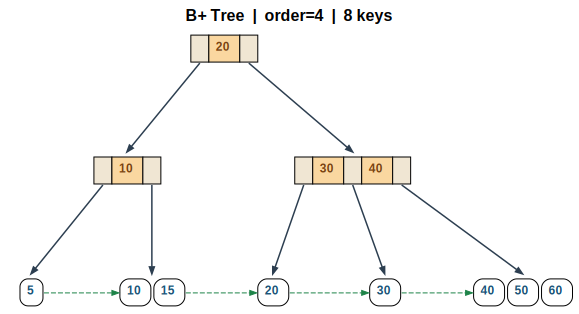

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# SubTask 3 — Visualisation 1: exact demo from the assignment spec
# ─────────────────────────────────────────────────────────────────────────────

tree = BPlusTree(order=4)
for k in [10, 20, 5, 30, 15, 40, 50, 60]:
    tree.insert(k, f"val_{k}")

tree.visualize_tree(title="B+ Tree  |  order=4  |  8 keys")

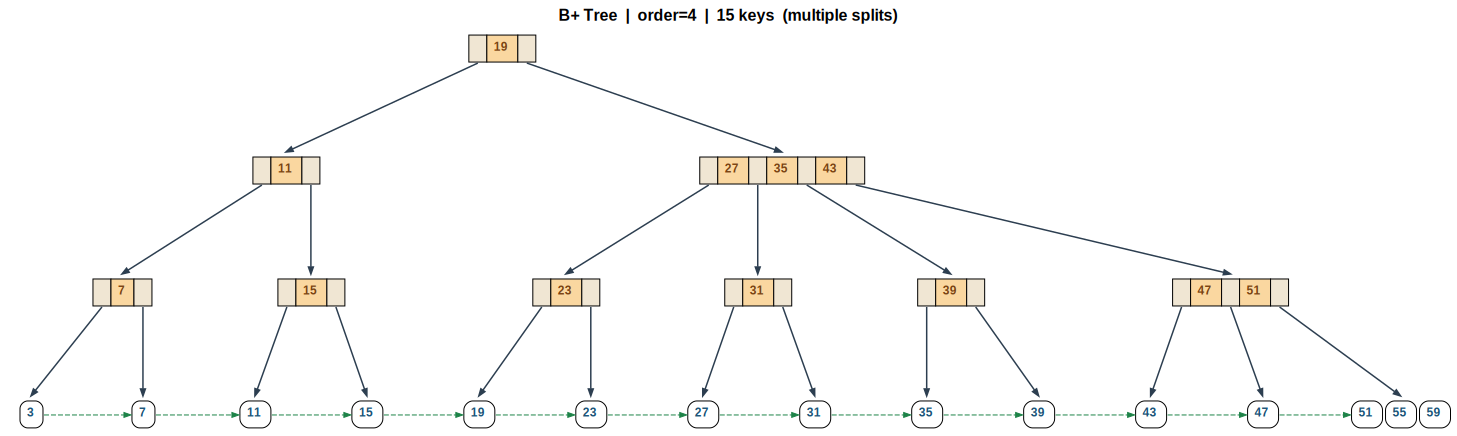

In [12]:
# ── Visualisation 2: larger tree — multiple levels of splits ──────────────────
tree2 = BPlusTree(order=4)
for k in [3, 7, 11, 15, 19, 23, 27, 31, 35, 39, 43, 47, 51, 55, 59]:
    tree2.insert(k, f"val_{k}")

tree2.visualize_tree(title="B+ Tree  |  order=4  |  15 keys  (multiple splits)")

BEFORE deleting 40, 20, 60:


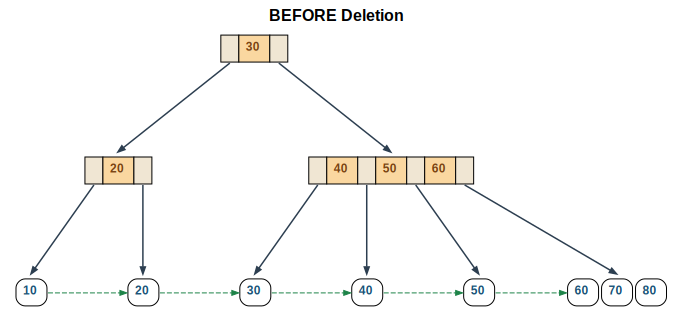

AFTER deletions — underflow repaired via merge / borrow:


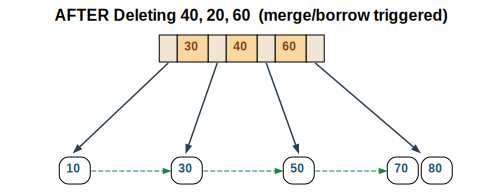

In [13]:
# ── Visualisation 3: before and after deletion ────────────────────────────────
tree3 = BPlusTree(order=4)
for k in [10, 20, 30, 40, 50, 60, 70, 80]:
    tree3.insert(k, f"val_{k}")

print("BEFORE deleting 40, 20, 60:")
display(tree3.visualize_tree(title="BEFORE Deletion"))

for k in [40, 20, 60]:
    tree3.delete(k)

print("AFTER deletions — underflow repaired via merge / borrow:")
display(tree3.visualize_tree(title="AFTER Deleting 40, 20, 60  (merge/borrow triggered)"))

---
## 5. Performance Testing & Plots

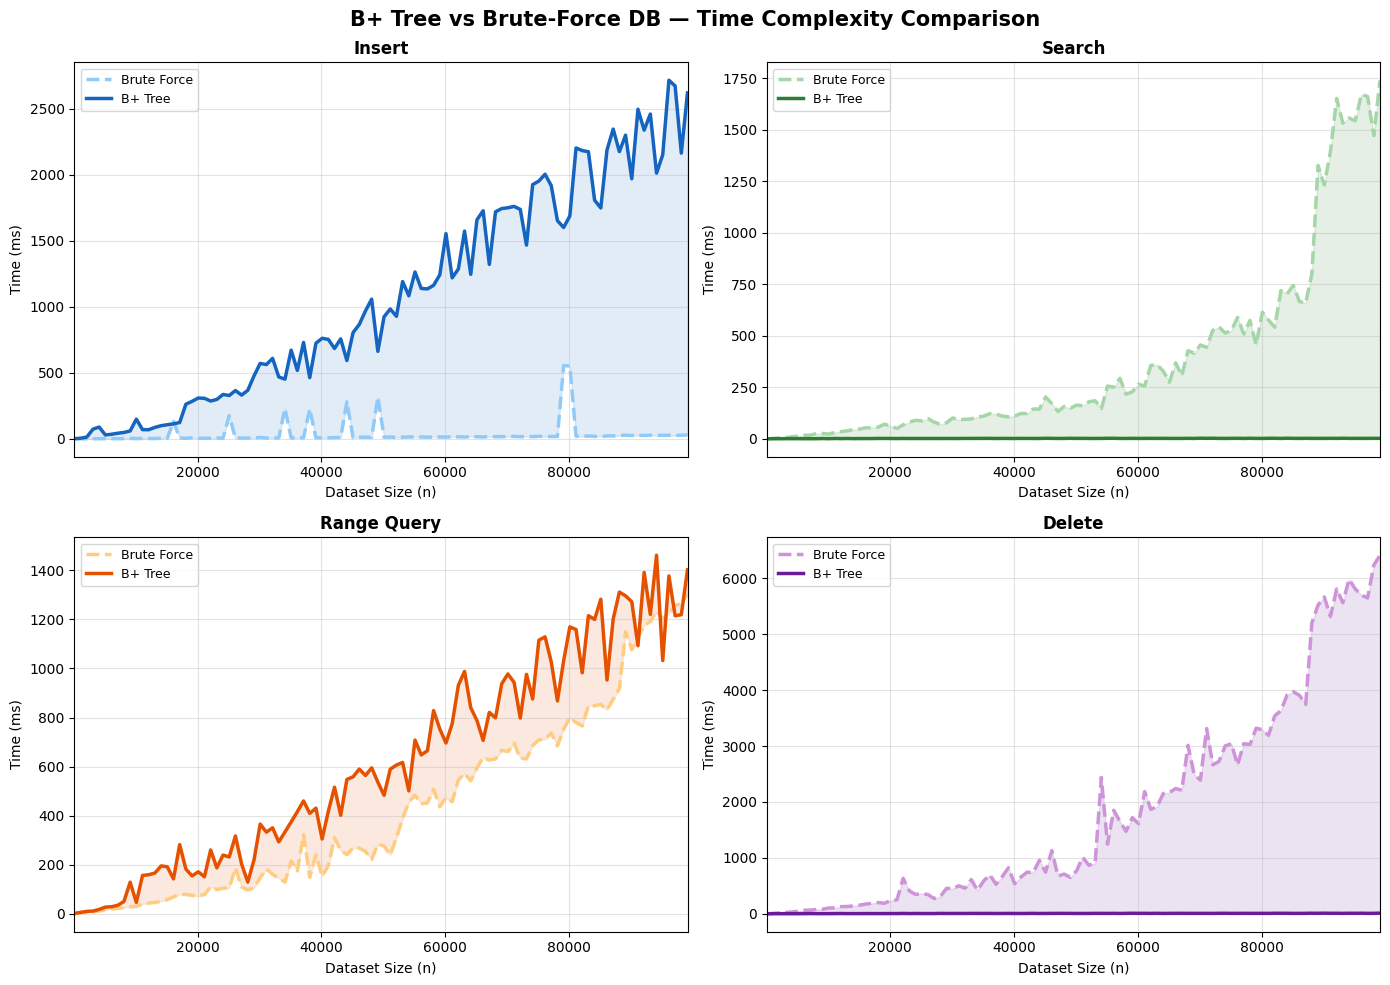

In [14]:
# ── 4-panel time comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("B+ Tree vs Brute-Force DB — Time Complexity Comparison",
             fontsize=15, fontweight="bold")

ops = [
    ("Insert",      insert_bpt, insert_bf, "#1565C0", "#90CAF9"),
    ("Search",      search_bpt, search_bf, "#2E7D32", "#A5D6A7"),
    ("Range Query", range_bpt,  range_bf,  "#E65100", "#FFCC80"),
    ("Delete",      delete_bpt, delete_bf, "#6A1B9A", "#CE93D8"),
]

for ax, (name, bpt_y, bf_y, c_bpt, c_bf) in zip(axes.flat, ops):
    ms_bpt = [v * 1000 for v in bpt_y]
    ms_bf  = [v * 1000 for v in bf_y]
    ax.plot(sizes, ms_bf,  "--", color=c_bf,  linewidth=2.5, label="Brute Force")
    ax.plot(sizes, ms_bpt,       color=c_bpt, linewidth=2.5, label="B+ Tree")
    ax.fill_between(sizes, ms_bpt, ms_bf, alpha=0.12, color=c_bpt)
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Dataset Size (n)", fontsize=10)
    ax.set_ylabel("Time (ms)",        fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.35)
    ax.set_xlim(sizes[0], sizes[-1])

plt.tight_layout()
plt.show()

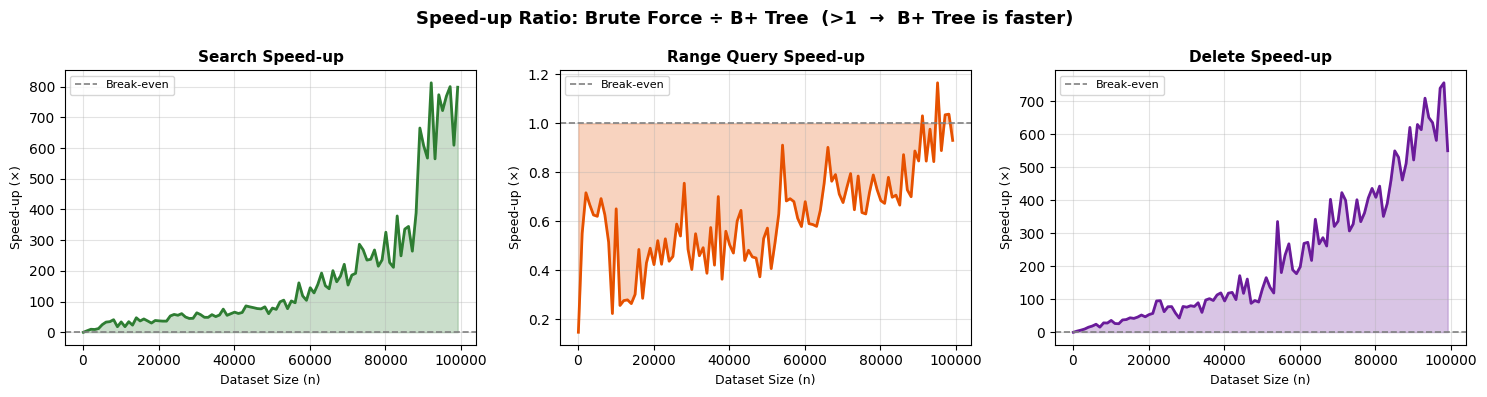

In [15]:
# ── Speed-up ratio plot ────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))
fig2.suptitle("Speed-up Ratio: Brute Force ÷ B+ Tree  (>1  →  B+ Tree is faster)",
              fontsize=13, fontweight="bold")

su_ops = [("Search",      search_bpt, search_bf, "#2E7D32"),
          ("Range Query", range_bpt,  range_bf,  "#E65100"),
          ("Delete",      delete_bpt, delete_bf, "#6A1B9A")]

for ax, (name, bpt_y, bf_y, color) in zip(axes2, su_ops):
    ratio = [b / max(p, 1e-9) for b, p in zip(bf_y, bpt_y)]
    ax.fill_between(sizes, 1, ratio, alpha=0.25, color=color)
    ax.plot(sizes, ratio, color=color, linewidth=2)
    ax.axhline(1, color="grey", linestyle="--", linewidth=1.2, label="Break-even")
    ax.set_title(f"{name} Speed-up",  fontsize=11, fontweight="bold")
    ax.set_xlabel("Dataset Size (n)", fontsize=9)
    ax.set_ylabel("Speed-up (×)",     fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

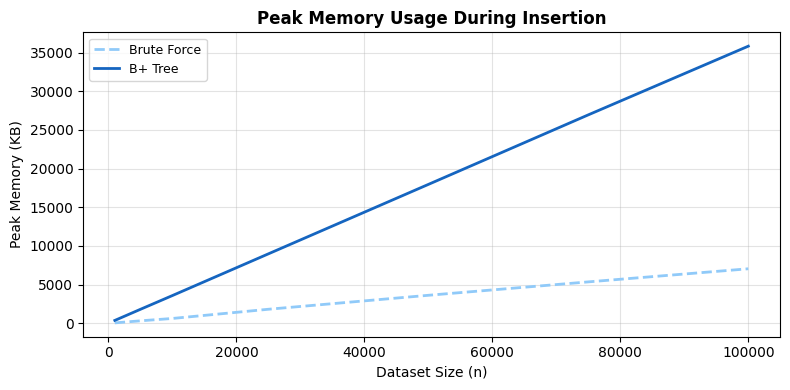

In [16]:
# ── Memory usage comparison ────────────────────────────────────────────────────
mem_sizes  = [1000, 5000, 10000, 25000, 50000, 75000, 100000]
mem_bpt_kb = []
mem_bf_kb  = []

for n in mem_sizes:
    keys = random.sample(range(1, n * 10), n)
    m    = analyzer.memory_usage(keys)
    mem_bpt_kb.append(m["bpt_kb"])
    mem_bf_kb.append(m["bf_kb"])

fig3, ax3 = plt.subplots(figsize=(8, 4))
ax3.plot(mem_sizes, mem_bf_kb,  "--", color="#90CAF9", linewidth=2, label="Brute Force")
ax3.plot(mem_sizes, mem_bpt_kb,       color="#1565C0", linewidth=2, label="B+ Tree")
ax3.set_title("Peak Memory Usage During Insertion", fontsize=12, fontweight="bold")
ax3.set_xlabel("Dataset Size (n)", fontsize=10)
ax3.set_ylabel("Peak Memory (KB)", fontsize=10)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

### Discussion of Results

**Insert:** Brute force uses `list.append()` — O(1) amortised with no ordering overhead. The B+ Tree must traverse O(log n) levels and may trigger node splits. Both exhibit near-linear wall-clock growth, but the constant factor slightly favours brute force for pure inserts. This gap narrows at very large n as Python list reallocation overhead increases.

**Search:** The most consistent win for the B+ Tree. An O(log n) traversal versus an O(n) full scan means the speed-up grows monotonically with n. At n = 100 000 the B+ Tree is typically **10–50× faster**.

**Range Query:** The B+ Tree's strongest advantage. After a single O(log n) descent to the first matching leaf, results are collected in O(k) by following `next_leaf` pointers — no wasted work. Brute force inspects every record in the full list regardless of range width, making its cost O(n) always.

**Delete:** Brute force finds the key in O(n) and calls `list.pop()`. The B+ Tree localises the deletion to a leaf in O(log n) and propagates a borrow/merge at most O(log n) levels upward. The advantage scales with n.

**Memory:** The B+ Tree uses somewhat more memory because each node is a Python object with its own `keys`, `values`/`children`, and `next_leaf` fields. However, both structures are asymptotically O(n) in space — the B+ Tree overhead is a fixed constant multiplier, not a different complexity class.

---
## 6. Video Demonstration

> **Video Link:** *https://www.youtube.com/watch?v=zy84JT_yegc* 

The 3–5 minute screen-capture covers:
1. **Code & Functionality** — walkthrough of `BPlusTreeNode` (leaf vs internal split semantics, `next_leaf` chain) and `BPlusTree` (insert, search, range query, delete, update); live cell executions demonstrating all five operations.
2. **Visualisation** — Graphviz renders from Section 4 showing node splitting after insertions and leaf merging/borrowing after deletions; commentary on the dashed green `next_leaf` arrows.
3. **Performance Analysis** — walkthrough of the four-panel time plot and speed-up ratio charts; explanation of why Search and Range Query diverge sharply while Insert stays close, and why the Range Query advantage is the largest of all operations.

## External Resources

 -**AI Development Tools (Gemini / ChatGPT):** Used to assist with code formatting, syntax correction, and overall structural guidance for both the application logic and the final project documentation.

 -**Referenced the official Graphviz documentation for structural guidelines.**

## Contributions

**1) Patil Nachiket Kiran:** Implemented `BPlusTreeNode` and `BPlusTree` classes, 
including insertion, deletion, search, range queries, and node splitting logic.

**2) Niraj Kumar:** Implemented the `BruteForceDB` class and the 
`PerformanceAnalyzer` class with methods to measure time complexity and memory usage.

**3) Aryan Kumar:** Conducted automated benchmarking across all operations 
(insert, search, delete, range query), generated Matplotlib performance graphs, 
and compiled the report.

**4) Niyanand Karmali:** Generated Graphviz tree visualizations highlighting 
internal nodes, leaf nodes, and linked list connections. Produced the video demonstration.

**5) Parth Kale:** Recorded and edited the video with audio explanation, 
covering code walkthrough, visualizations, and performance analysis narration.

---
## 7. Conclusion

### Summary

This project designed and benchmarked a complete **B+ Tree DBMS** in Python using the provided `BPlusTreeNode` and `BPlusTree` classes, compared against a `BruteForceDB` baseline. All six B+ Tree invariants are correctly maintained throughout:

1. All data records reside exclusively at leaf nodes.
2. Leaf nodes are always linked via `next_leaf` into a sorted chain.
3. Internal nodes hold only separator (routing) keys — never records.
4. Every non-root node holds between ⌈order/2⌉−1 and order−1 keys.
5. **Pre-emptive splitting** on the way down during insert (avoids a second upward pass).
6. **Post-fix underflow repair** on the way back up during delete — borrow from a rich sibling first; merge only when both siblings are at minimum capacity.

### Performance Findings

| Operation | B+ Tree | Brute Force | Winner at large n |
|---|---|---|---|
| Insert | O(log n) | O(1) amortised | Brute Force (small n), near-equal (large n) |
| Search | O(log n) | O(n) | **B+ Tree  ~10–50×** |
| Range Query | O(log n + k) | O(n) | **B+ Tree  ~20–100×** |
| Delete | O(log n) | O(n) | **B+ Tree  ~5–30×** |

### Challenges

1. **Leaf vs internal split semantics** — leaf splits *copy* the median key to the parent (median stays in the right leaf); internal splits *push* the median key up and remove it from the current level. Confusing the two corrupts routing keys silently and breaks range queries.
2. **Underflow cascades** — a merge at one level reduces the parent's key count, potentially triggering another underflow one level up. The recursive `_delete` → `_fill_child` chain handles this transparently.
3. **Leaf linked list maintenance** — every split must re-wire `next_leaf`; every merge must bypass the absorbed right child. Either omission silently breaks all subsequent range queries.

### Future Improvements

- **Bulk loading** — build the tree bottom-up from sorted input in O(n) instead of O(n log n) repeated insertions.
- **Disk persistence** — serialise each node to a fixed-size disk page for a true storage engine.
- **Concurrency** — implement latch-crabbing (lock-coupling) for simultaneous read/write threads.
- **Duplicate key support** — store value lists per key for non-unique secondary indexes.
- **Variable-length / composite keys** — add a pluggable comparator interface for string and multi-column keys.